<a href="https://colab.research.google.com/github/HariNiveditha/RideDemandForecast/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/RideDemandForecast"

print(os.path.exists(base_path))
print(os.listdir(base_path))

True
['nyc%202021-01-01%20to%202021-12-31.csv', 'taxi_zone_lookup.csv', 'fhvhv_tripdata_2021-05.parquet', 'fhvhv_tripdata_2021-04.parquet', 'fhvhv_tripdata_2021-06.parquet', 'weather_cleaned.parquet', 'hourly_demand_04.parquet', 'hourly_demand_05.parquet', 'hourly_demand_06.parquet', 'data_loading&cleaning.ipynb', 'EDA.ipynb']


In [ ]:
import pandas as pd

april = pd.read_parquet(f"{base_path}/hourly_demand_04.parquet")
may = pd.read_parquet(f"{base_path}/hourly_demand_05.parquet")
june = pd.read_parquet(f"{base_path}/hourly_demand_06.parquet")

trip_df = pd.concat(
    [april, may, june],
    ignore_index=True
)

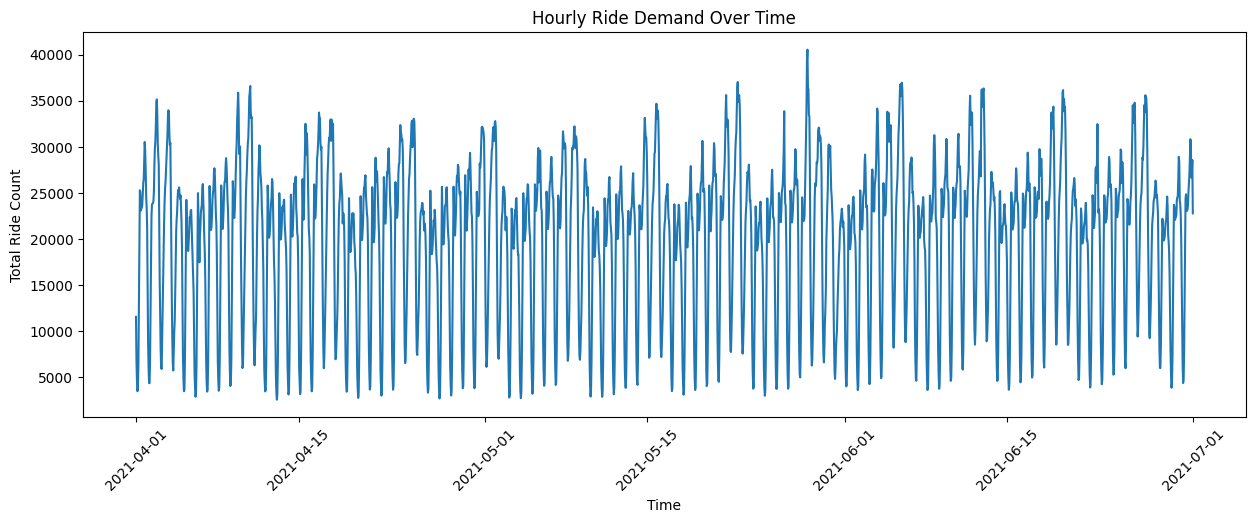

In [ ]:
import matplotlib.pyplot as plt
total_hourly = (
    trip_df.groupby("pickup_hour")["ride_count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,5))
plt.plot(total_hourly["pickup_hour"], total_hourly["ride_count"])
plt.xlabel("Time")
plt.ylabel("Total Ride Count")
plt.title("Hourly Ride Demand Over Time")
plt.xticks(rotation=45)
plt.show()